###### Abstract

Convolutional neural network (CNN), a class of artificial neural networks that has had increased popularity in various machine and deep learning tasks and possibly the dominant, has lately attracted interest across a variety of domains including radiology. CNN strength is premised on its design to automatically and adaptively learn spatial hierarchies of features through backpropagation through use of multiple building blocks such as convolution layers, pooling layers and fully connected layers. This article offers a perspective on the basic concepts of CNN and its application to time series analysis in an attempt to predict the Covid-19 pandemic trends. Notwithstanding the inherent challenges in applying CNN to this tasks namely, relatively small dataset and overfitting for lagged time series analysis. The article will delve on techniques to minimize the alluded challenges in order to reap full benefits of CNN.


#### Background
Lake Mutirikwi, located in Masvingo Province, Zimbabwe, is one of the country’s largest inland water reservoirs, with a nominal storage capacity of approximately 1.378 billion cubic meters. It plays a critical role in supporting irrigation, domestic water supply, and economic activities in the surrounding Lowveld region. However, due to sedimentation, climate variability, and inadequate infrastructure maintenance, the actual water-holding capacity of the dam is believed to have changed significantly over the years. Understanding these changes is essential for sustainable water resource planning and agricultural decision-making.

Traditional approaches to estimating dam capacity involve bathymetric surveys or direct volumetric measurements. While accurate, these methods are costly, labor-intensive, and logistically challenging, especially in resource-constrained settings. In contrast, satellite-based remote sensing offers a low-cost, scalable alternative for continuously monitoring water bodies. Among these, Landsat 5 and 7 missions provide long-term, publicly available imagery with sufficient spatial and temporal resolution to observe surface water extent changes over time.

Conventional remote sensing techniques have used the classified surface area of reservoirs—typically derived through spectral indices such as NDWI or supervised classification—as a proxy for estimating capacity. Empirical models or traditional machine learning algorithms (e.g., linear regression, random forest, or support vector regression) have then been employed to approximate the area-to-volume relationship. However, these models often require manual feature extraction and may not fully capture the spatial heterogeneity and contextual patterns present in satellite images.

With the advancement of deep learning, Convolutional Neural Networks (CNNs) have emerged as a powerful tool for modeling spatial data, particularly image-based tasks. Unlike traditional regression methods, CNNs automatically learn and extract spatial features such as shape, texture, and contextual relationships from raw pixel values. This makes them well-suited for predicting dam capacity directly from classified or even raw satellite imagery, especially when large volumes of training data are available or can be synthesized.

This research explores the use of CNN-based regression models to predict the water storage capacity of Lake Mutirikwi from classified dam area coverage derived from historical Landsat 5 and 7 images. The CNN is trained to learn the non-linear relationship between spatial water patterns and known capacity values from historical periods. Once trained, the model can infer capacity estimates for time periods or dam conditions where ground-truth measurements are missing.

The study applies techniques from data preprocessing and image segmentation to CNN model design, training, and evaluation, bridging the domains of remote sensing, hydrology, and artificial intelligence. By focusing on Lake Mutirikwi as a case study, this work demonstrates how deep learning can be used to close data gaps and support water management decisions in regions where traditional measurement methods are infeasible. It contributes to the field of environmental informatics, showcasing the potential of CNNs to solve real-world environmental challenges through data-driven innovation.

<hr style='height: 1px; background-color: black; border: none;'>

## Conceptual Framework

This study is grounded in the principle that spatial patterns in remotely sensed imagery of dam surface areas contain latent features that correlate strongly with dam water volume. Traditional methods for estimating dam capacity from classified surface area rely on explicit mathematical or empirical relationships. In contrast, this study leverages Convolutional Neural Networks (CNNs) to learn such relationships directly from the imagery data in a data-driven manner.

The conceptual framework integrates four core components:

   * Satellite Remote Sensing Data
    Landsat 5 and 7 imagery are used to extract classified surface water extents of Lake Mutirikwi. This represents the input feature space.

   * Data Preprocessing and Area Classification
    Spectral indices such as NDWI, thresholding, or supervised classification are applied to isolate water bodies from the imagery. Each classified image is associated with a known historical dam capacity (from hydrological records or derived estimates).

   * CNN-Based Regression Model
    The core of the framework is a CNN regression model that takes the spatial representation (images or masks of the dam area) as input and predicts the dam’s storage capacity in cubic meters. The model is trained to learn the spatial dependencies and patterns that influence volume.

   * Prediction and Evaluation
    The trained CNN is used to estimate dam capacity for periods without recorded measurements. Evaluation metrics like MAE, RMSE, and R² are used to assess model accuracy.

### Relevant Concepts & Relationships


|               <b>Component</b>         |                  	<b>Description</b>                                    |
|----------------------------------------|----------------------------------------------------------------------------|
|Satellite Imagery (Landsat 5/7)         |	Source of spatial-temporal information capturing surface water extent.    |
|Preprocessing & Classification          |	NDWI or thresholding is used to delineate dam surface area.               |
|Input to CNN                            |	Calculated area coverage of lassified 2D water body                       |
|CNN Model (Regression Output)           |Learns spatial and contextual features to estimate dam capacity in ${m^3}$  |
|Target Variable                         |	Known or estimated dam capacity measurements used as labels.              |
|========================================|============================================================================|


### Theoretical Underpinning

   *     Hydrological Principle: </br>
   There exists a non-linear but physically grounded relationship between the surface area of a dam and its storage volume. This relationship is influenced by the dam’s bathymetry and catchment hydrology, and serves as the foundational assumption that variations in observed surface area reflect underlying capacity changes. </br></br>

   * Computer Vision Theory (Enhanced with NDWI Application): </br>
    Remote sensing imagery can be processed using computer vision techniques to identify and extract spatial features that correlate with physical water bodies. In this study, the Normalized Difference Water Index (NDWI) is utilized as a spectral index to enhance the detection of surface water in Landsat imagery. The NDWI emphasizes water content by contrasting green and near-infrared reflectance, enabling reliable classification of dam surface areas. These classified water masks are converted to pixel counts and subsequently translated into area coverage (in square meters). This spatial representation then forms the input into CNN models, which extract patterns and infer relationships between water extent and capacity that may not be explicitly visible through traditional feature engineering.</br></br>

   * Data-Driven Inference: </br>
    Convolutional Neural Networks (CNNs) are employed to learn complex, latent relationships between classified dam area coverage and known volumetric measurements. Through supervised training on historical time-series data, CNNs can generalize and predict dam capacity in instances where direct hydrological measurements are missing. This approach leverages the model’s ability to learn abstract spatial hierarchies and apply them to unseen scenarios with high predictive accuracy.</br></br>



## Framework Diagram (Conceptual Flow)

<p>
    
    | Landsat 5 & 7 Imagery        |
    |------------------------------|

                  |
                  v
              

    | Water Body Classification    | ← NDWI / Thresholding / Supervised
    |------------------------------|

                  |
                  v
              
    | Preprocessed Classified Mask |
    |------------------------------|

                  |
                  v

    | CNN Regression Model         | → Learns spatial patterns in image
    |------------------------------|

                  |
                  v

    | Predicted Dam Capacity (m³)  |
    |------------------------------|

</p>


### Methodology (Simplified Overview)
1. Study Area and Dataset

    Location: Lake Mutirikwi, Masvingo Province, Zimbabwe

    Imagery: Landsat 5 (1984–2012) and Landsat 7 (1999–present)

    Resolution: 30 meters

    Ground Truth: Historical dam capacity data from Zimbabwe National Water Authority (ZINWA) or estimations from DEM/bathymetry.

2. Image Preprocessing

    Download Landsat scenes with <10% cloud cover.

    Apply atmospheric correction (e.g., LEDAPS or Surface Reflectance).

    Mask water bodies using NDWI or supervised classification.

    Create binary masks or grayscale classified images.

3. Dataset Preparation

    Resize classified masks to a fixed CNN input size (e.g., 64x64 or 128x128).

    Normalize input data.

    Associate each mask with actual dam capacity (target value).

4. Model Architecture

    CNN with:

        Input: Preprocessed classified image (e.g., 1-channel, 64x64)

        2–3 convolutional layers

        Pooling and dropout for regularization

        Fully connected layers

        Output: Single regression output (volume in m³)

5. Training and Validation

    Split into train, validation, and test sets (e.g., 70/15/15).

    Loss function: Mean Squared Error (MSE)

    Optimizer: Adam

    Epochs: 50–200 (early stopping based on validation)

6. Evaluation

    Metrics: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), R²

    Visualization: Plot predicted vs actual dam capacities


#### Introduction to Time Series Analysis 

In the broad form, an analysis is conducted to obtain inference of what has occurred in the past with the data point series and endeavour to predict what is going to appear in the coming time. An ordered set of observations with respect to time periods is a time series. In simple words, a sequential organization of data accordingly to their time of occurrence is termed as time series.

A time series data is the set of measurements taking place in a constant interval of time, here time acts as independent variable and the objective ( to study changes in a characteristics) is dependent variables.  

#### The time series data is of three types:
* Time series data: A set of observations contains values, taken by variable at different times.
* Cross-sectional data: Data values of one or more variables, gathered at the same time-point.
* Pooled data: A combination of time series data and cross-sectional data.

A time-series data can be represented using various data visualization techniques in order to uncover the hidden patterns in  datasets.

#### Implementing Time Series Analysis in Machine Learning
 
It is a well-known fact that Machine Learning is a powerful technique in imaging, speech and natural language processing for a huge explicated dataset available. On the other hand, problems based on time series do not have usually interpreted datasets, even as data is collected from various sources so exhibit substantial variations in terms of;
* features, 
* properties, 
* attributes, 
* temporal scales, 
* and dimensionality.
Time series analysis requires such sorting algorithms that can allow it to learn time-dependent patterns across multiples models different from images and speech. Various machine learning tools such as classification, clustering, forecasting, and anomaly detection depend upon real-world business applications.

It is an important area of machine learning because there are multiple problems involving time components for making predictions. There are multiple models and methods used as approaches for time series forecasting, let us understand them more clearly;

#### ML Methods For Time-Series Forecasting

In the Univariate Time-series Forecasting method, forecasting problems contain only two variables in which one is time and the other is the field we are looking to forecast.  

On the other hand, in the Multivariate Time-series Forecasting method, forecasting problems contain multiple variables keeping one variable as time fixed and others will be multiple in parameter. Consider the same example, predicting the temperature of a city for the coming week, the only difference would come here now temperature will consider impacting factors such as
* Rainfall and time duration of raining,
* Humidity,
* Wind speed,
* Precipitation,
* Atmospheric pressure, etc,

And then the temperature of the city will be predicted accordingly. All these factors are related to temperature and impact it vigorously. In this paper, the problem is Multivariate time-series forecasting as we are required to forecast confirmed cases for November and December and these are based on daily, active, recovered, deaths cases.

#### 5-Step Forecasting Task

The 5 basic steps in a forecasting task are summarized by Hyndman and Athana­sopou­los in their book Forecasting: principles and practice. These steps are:

* Problem Definition. 
  The careful consideration of who requires the forecast and how the forecast will be used. This is described as the most difficult part of the process, most likely because it is entirely problem specific and subjective.

* Gathering Information. 
  The collection of historical data to analyze and model. This also includes getting access to domain experts and gathering information that can help to best interpret the historical information, and ultimately the forecasts that will be made.

* Preliminary Exploratory Analysis. 
  The use of simple tools, like graphing and summary statistics, to better understand the data. Review plots and summarize and note obvious temporal structures, like trends seasonality, anomalies like missing data, corruption, and outliers, and any other structures that may impact forecasting.
  
* Choosing and Fitting Models. 
  Evaluate two, three, or a suite of models of varying types on the problem. Models may be chosen for evaluation based on the assumptions they make and whether the dataset conforms. Models are configured and fit to the historical data.

* Using and Evaluating a Forecasting Model. 
  The model is used to make forecasts and the performance of those forecasts is evaluated and skill of the models estimated. This may involve back-testing with historical data or waiting for new observations to become available for comparison.

This 5-step process provides a strong overview from starting off with an idea or problem statement and leading through to a model that can be used to make predictions. However, in the case of this article, problem definition is covered by the rubric of the assignment and expectations. The other four steps will guide and inform on the approaches in the broad sense to solving this problem/questions.

In terms of data gathering, we will explore reputable data in the dam_analsis database capturing information from classification model and the verified excel sheet statistics from Zinwa.

After gathering the suitable and most appropriate dataset, we will delve into exploratory analysis of the data to discover patterns and insights in the data. this will be covered specifically in Section 3 of this paper and results captured and documented accordingly.

This abstract idea sums the approach to be followed in solving this problem. in addition to the detailed above 5 major steps the process extends beyond the development of a model and making forecasts and involves iterative loops. Their process can be summarized as follows:

* Define Goal.
* Get Data.
* Explore and Visualize Series.
* Pre-Process Data.
* Partition Series.
* Apply Forecasting Method/s.
* Evaluate and Compare Performance.
* Implement Forecasts/Systems.
* Below are the iterative loops within the process:

Explore and Visualize Series => Get Data. Data exploration can lead to questions that require access to new data.

Evaluate and Compare Performance => Apply Forecasting Method/s. The evaluation of models may raise questions or ideas for new methods or new method configurations to try.

The process is more focused on the ongoing development and refinement of one or more models on the problem until an acceptable level of performance is achieved.

This process can continue where models are revised and updated as new data and new insights are made available.


In this article the researcher will explore the use of machine learning and artificial science in the analysis dam capacity and water area coverage in Zimbabwe and glean insights to historic patterns and trends. The trend identified will be utilised to make an attempt to predict capacity on a need basis. In addition to the forecasts, the researcher will also make an attempt to forecast current years capacity. The remaining of the paper is organized as follows;
* Section 1: Clear explanation of the data, data source and features
* Section 2: Objective of the Data Analytics E.g. (Classification, Predictive Analytics, Regression etc.)
* Section 3: Detailed Exploratory Data Analytics without using the Pandas Profiler
* Section 4: Detailed Feature Engineering
* Section 5: Explanation of Machine Learning / Deep learning algorithm and parameters used
* Section 6: Architecture diagram of Machine learning / Deep learning algorithm
* Section 7: Demonstrate Hyperparameter Tuning done to boost performance of the model
* Section 8: Performance Metrics report of the Machine learning / Deep learning algorithm
* Section 9: The analytics outcome (What insights can you provide from this data)
* Section 10: Conclusion and Remarks


<hr style='height: 1px; background-color: black; border: none;'>

## Section 1: Clear explanation of the data, data source and features


#### Source of the Dataset

The datasets for this project assignment were obtained from


* ZINWA dam capacity database

* Table water_stats in dam_analysis database, capturing output from classification model


#### Feature  and Description

Water_stats contain the following columns;

|<b>Name of Colums  </b>    |<b>         Description         </b>                                                      |
|---------------------------|------------------------------------------------------------------------------------------|
|<b>date</b>                |<b>Denotes the date the image processed to achieve the stats was taken</b>                |
|<b>water_area</b>          |<b>Denotes surface area covered by water measured in square meters ${m^2}$</b>            |
|<b>water_percentage</b>    |<b>Percentage of water area to total area for the Region of Interest polygon</b>          |
|<b>non_water_area</b>      |<b>Denotes surface area covered by non water classes measured in square meters ${m^2}$</b>|
|<b>non_water_percentage</b>|<b>Percentage of non water area to total area for the Region of Interest polygon</b>      |
|<b>total_area</b>          |<b>Total area for the Region of Interest polygon</b>                                      |
|===========================|==========================================================================================|

and Mutirikwi Dam data contain the following columns

|<b>Name of Colums  </b>    |<b>         Description         </b>                                                      |
|---------------------------|------------------------------------------------------------------------------------------|
|<b>DAM_NAME</b>            |<b>Name of the Dam/Lake</b>                                                               |
|<b>WEEKDATE</b>            |<b>Date the dam capacity measurements were taken</b>                                      |
|<b>MonthYear</b>           |<b>Short Month-Year format for the date on which measurements were taken</b>              |
|<b>DAM_LEVEL</b>           |<b>Measured capacity on the date expressed as percentage of dam full holding capacity</b> |
|<b>DAM_PRCAP</b>           |<b>Dam Water capacity in ${m^3}$ on the day measurements were taken</b>                    |
|===========================|==========================================================================================|

<hr style='height: 1px; background-color: black; border: none;'>

## Section 2: Objective of the Data Analytics E.g. (Classification, Predictive Analytics, Regression etc.)

#### Objective
The objective of this study is to utilise machine learning and artificial intelligence in anaylsis of Zimbabwe's Lake Mutirikwi water capacity based on water surface area coverage, predict capacity on a need basis based on classified water area and predicting future water capacity based on historic trends to prepare for potential low water spell seasons.

#### Methods
A systematic time series analysis of capacity and coverage area for Mutirikwi will be conducted. The time series analysis will be done using convolutional neural networks and pursue a model accuracy of 88%

#### Type of Data Analytics

This project explores a predictive analytics. In this article, we will utilise the multivariate data for confirmed lake Mutirikwi water capacity (DAM_PRCAP), based on water_area (water covered area (${m^2}$)), non_water_area (non water covered area (${m^2}$)), and date variables. 

<hr style='height: 1px; background-color: black; border: none;'>

## Section 3: Detailed Exploratory Data Analytics without using the Pandas Profiler


<b>Exploratory data analysis (EDA)</b> is a crucial component of data science which allows one to develop an insight of what the data looks like and what kinds of questions might be answered by the data. It seeks to establish inherent relations among variables, outliers, distributions and skewness. In other terms it employs descriptive statistics to give us an idea of our data, its description in terms of measures of central tendency or variability.

EDA is specifically critical for:-
1. Cleansing: Checking for problems with the collected data such as missing data, measurement error or data type of columns.Data cleansing is the first and a very crucial step in the overall data preparation process and is the process of analysing, identifying and correcting messy raw data. When analysing organisational data to make strategic decisions it must be ensured the starting point is a thorough data cleansing process.
2. Defining questions: Identifying relationships between variables that are particularly interesting or unexpected. The main goal here is to identify and create relationships which can help you to build a hypothesis. 
3. Using effective visualizations to communicate my results

The scope of this section will be to get general insights of the datasets, that is, both train and test sets for such features like;
* seasonality
* correlations
* trends
* missing values
* dataset shape

First we import and load out datasets.

In [ ]:
!pip install pydot

In [1]:
# Loading packages
import io
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
import numpy as np
import pandas as pd
import requests
import math
import tensorflow as tf
from numpy import array
from numpy import hstack
from datetime import datetime
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pandas.plotting import autocorrelation_plot
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.layers.convolutional import Conv1D, MaxPooling1D
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_squared_log_error 
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.utils import plot_model
from keras.callbacks import ModelCheckpoint
from keras.callbacks import EarlyStopping
from math import sqrt
from keras.models import load_model
from tensorflow.keras.wrappers.scikit_learn import KerasRegressor
from sklearn.model_selection import GridSearchCV
import missingno as msno
import pyodbc  
from dotenv import load_dotenv as ld 
from urllib.parse import quote_plus

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import warnings
warnings.filterwarnings('ignore')

In [2]:
# See plot attributes
plt.style.use('fivethirtyeight')
matplotlib.rcParams['axes.labelsize'] = 10
matplotlib.rcParams['ytick.labelsize'] = 10
matplotlib.rcParams['xtick.labelsize'] = 10
matplotlib.rcParams['text.color'] = 'k'
matplotlib.rcParams['figure.figsize'] = 10, 7

In [3]:
excepts = ['1992-11-12', '1995-03-26', '1995-06-14', '1995-06-30', '2013-05-22', '2013-07-09', '2013-07-25', '2013-11-14',
           '2015-03-25', '2015-06-13', '2015-07-15', '2015-07-31', '2015-08-16', '2015-09-01', '2016-01-07', '2016-04-28',
           '2016-05-14', '2016-06-15', '2016-07-01', '2019-05-07', '2019-06-24', '2019-07-26', '2019-12-01', '2020-04-07', 
           '2020-04-30', '2020-05-25', '2020-06-10', '2020-07-12', '2020-09-21', '2020-10-16', '2020-11-17', '2021-07-22',
           '2021-08-07', '2021-09-24', '2022-05-24', '2022-06-10', '2022-07-31', '2022-08-12', '2022-08-17', '2022-08-29', 
           '2022-09-03', '2022-10-02', '2022-10-07', '2023-03-19', '2023-04-27', '2023-06-15', '2023-07-02', '2023-07-24', 
           '2023-08-20', '2023-09-21', '1991-04-16', '1991-05-02', '1992-06-21', '1992-08-24', '1992-09-09', '1995-07-16', 
           '1995-08-01', '1995-09-02', '1995-11-05', '1998-06-22', '2009-09-16', '2010-09-19', '2012-05-03', '2012-06-20', 
           '2012-08-07', '2012-07-22', '2012-05-19'
          ]
excepts = [datetime.strptime(date_str, "%Y-%m-%d").date() for date_str in excepts]
excepts

[datetime.date(1992, 11, 12),
 datetime.date(1995, 3, 26),
 datetime.date(1995, 6, 14),
 datetime.date(1995, 6, 30),
 datetime.date(2013, 5, 22),
 datetime.date(2013, 7, 9),
 datetime.date(2013, 7, 25),
 datetime.date(2013, 11, 14),
 datetime.date(2015, 3, 25),
 datetime.date(2015, 6, 13),
 datetime.date(2015, 7, 15),
 datetime.date(2015, 7, 31),
 datetime.date(2015, 8, 16),
 datetime.date(2015, 9, 1),
 datetime.date(2016, 1, 7),
 datetime.date(2016, 4, 28),
 datetime.date(2016, 5, 14),
 datetime.date(2016, 6, 15),
 datetime.date(2016, 7, 1),
 datetime.date(2019, 5, 7),
 datetime.date(2019, 6, 24),
 datetime.date(2019, 7, 26),
 datetime.date(2019, 12, 1),
 datetime.date(2020, 4, 7),
 datetime.date(2020, 4, 30),
 datetime.date(2020, 5, 25),
 datetime.date(2020, 6, 10),
 datetime.date(2020, 7, 12),
 datetime.date(2020, 9, 21),
 datetime.date(2020, 10, 16),
 datetime.date(2020, 11, 17),
 datetime.date(2021, 7, 22),
 datetime.date(2021, 8, 7),
 datetime.date(2021, 9, 24),
 datetime.date(20

#### Loading the Datasets

In [4]:
# Load environment variables from .env file
ld()


def read_sql():
    server = os.getenv('SQL_SERVER')
    database = os.getenv('SQL_DATABASE')
    username = os.getenv('SQL_USERNAME')
    password = os.getenv('SQL_PASSWORD')
    
    if not all([server, database, username, password]):
        raise ValueError("Missing required database connection parameters in .env file")

    # Create connection string with proper escaping
    connection_string = (
        f"DRIVER={{ODBC Driver 17 for SQL Server}};"
        f"SERVER={server};"
        f"DATABASE={database};"
        f"UID={username};"
        f"PWD={password}"
    )
    # Establishing connection
    conn = pyodbc.connect(connection_string)
    cursor = conn.cursor()
    
    query = '''
        SELECT [date]
              ,[water_area]
              ,[water_percentage]
              ,[non_water_area]
              ,[non_water_percentage]
              ,[total_area]
        FROM [dam_analysis].[dbo].[water_stats]
        '''

    # Fetch data in chunks
    water_stats = pd.read_sql_query(query, conn)
    # Close cursor and connection
    cursor.close()
    conn.close()

    return water_stats

True

In [5]:
water_stats = read_sql()
water_stats.head()

,date,water_area,water_percentage,non_water_area,non_water_percentage,total_area
0,1984-04-12,1.684267e+08,29.077952,4.107982e+08,70.922048,5.792249e+08
1,1984-07-01,2.264662e+08,39.098148,3.527587e+08,60.901852,5.792249e+08
2,1984-09-03,1.523730e+08,26.306359,4.268519e+08,73.693641,5.792249e+08
3,1986-07-23,1.773470e+08,30.617980,4.018780e+08,69.382020,5.792249e+08
4,1986-08-24,1.494730e+08,25.805700,4.297519e+08,74.194300,5.792249e+08


In [ ]:
# Read column names from file

capacity1 = pd.read_excel(r'C:\Users\\mutirikwi dataset\DAM_Mutirikwi (UPDATED).xlsx',
                         sheet_name='DAM_RETRIEVAL',
                         header=0)
capacity1.rename(columns={'WEEK_DATE':'WEEKDATE'}, inplace=True)
capacity1.head()

,DAM_NAME,WEEKDATE,DAM_LEVEL,DAM_PRCAP
0,MUTIRIKWI,2020-01-03,88.93,511.502
1,MUTIRIKWI,2020-01-06,88.70,500.014
2,MUTIRIKWI,2020-01-10,88.71,500.510
3,MUTIRIKWI,2020-01-13,88.86,507.989
4,MUTIRIKWI,2020-01-17,88.76,502.995


In [ ]:
capacity = pd.read_excel(r'C:\Users\mutirikwi dataset\MUTIRIKWI DAM.xlsx',
                         sheet_name='DAM_RETRIEVAL',
                         header=0)
capacity.head()

,DAM_NAME,WEEKDATE,MonthYear,DAM_LEVEL,DAM_PRCAP
0,MUTIRIKWI,1970-01-05,1970-01-05,75.88,90.723
1,MUTIRIKWI,1970-01-12,1970-01-12,75.63,86.298
2,MUTIRIKWI,1970-01-19,1970-01-19,75.02,77.130
3,MUTIRIKWI,1970-01-26,1970-01-26,74.31,65.079
4,MUTIRIKWI,1970-02-02,1970-02-02,73.66,55.026


In [8]:
capacity = pd.concat([capacity, capacity1], ignore_index=True)
capacity.head()

,DAM_NAME,WEEKDATE,MonthYear,DAM_LEVEL,DAM_PRCAP
0,MUTIRIKWI,1970-01-05,1970-01-05,75.88,90.723
1,MUTIRIKWI,1970-01-12,1970-01-12,75.63,86.298
2,MUTIRIKWI,1970-01-19,1970-01-19,75.02,77.130
3,MUTIRIKWI,1970-01-26,1970-01-26,74.31,65.079
4,MUTIRIKWI,1970-02-02,1970-02-02,73.66,55.026


### Checking Columns Data Types 

In [9]:
water_stats.info(), capacity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  186 non-null    object 
 1   water_area            186 non-null    float64
 2   water_percentage      186 non-null    float64
 3   non_water_area        186 non-null    float64
 4   non_water_percentage  186 non-null    float64
 5   total_area            186 non-null    float64
dtypes: float64(5), object(1)
memory usage: 8.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3817 entries, 0 to 3816
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   DAM_NAME   3817 non-null   object        
 1   WEEKDATE   3817 non-null   datetime64[ns]
 2   MonthYear  3243 non-null   datetime64[ns]
 3   DAM_LEVEL  3817 non-null   float64       
 4   DAM_PRCAP  3817 non-null   float64       
d

(None, None)

In [10]:
water_stats['date'] = water_stats['date'].astype('datetime64[ns]')

In [11]:
len(water_stats), len(excepts)
water_stats = water_stats.loc[~(water_stats['date'].isin(excepts))]
len(water_stats)

(186, 67)

119

In [12]:
len(water_stats), len(capacity)

(119, 3817)

In [13]:
list1 = []
list2 = []
list3 = []
for i in water_stats.date:
    minDiff = 30
    for j in capacity.WEEKDATE:
        if (i.year == j.year) & (i.month >= (j.month-1)) & (i.month <= (j.month+1)):
            diff = i-j
            diff = math.sqrt(int(str(diff).split()[0])**2)
            if diff<minDiff:
                minDiff = diff
                list1.append(i)
                list2.append(j)
                list3.append(minDiff)
dates = pd.DataFrame(zip(list1, list2, list3), columns = ['date', 'WEEKDATE', 'Diff'])
dates.drop_duplicates(subset = ['date'], keep='last', inplace=True, ignore_index=True)
dates.reset_index(drop=True, inplace=True)
len(dates)

114

In [14]:
dates=dates[['date', 'WEEKDATE']]
dates.head(20)

,date,WEEKDATE
0,1984-04-12,1984-04-09
1,1984-07-01,1984-07-02
2,1984-09-03,1984-09-03
3,1986-07-23,1986-07-25
4,1986-08-24,1986-08-22
5,1987-01-31,1987-01-30
6,1989-08-16,1989-08-17
7,1989-09-17,1989-09-15
8,1990-04-13,1990-04-12
9,1990-08-03,1990-08-03


In [15]:
water_stats = water_stats.merge(dates, how='inner', on='date')
water_stats.head(30)

,date,water_area,water_percentage,non_water_area,non_water_percentage,total_area,WEEKDATE
0,1984-04-12,1.684267e+08,29.077952,4.107982e+08,70.922048,5.792249e+08,1984-04-09
1,1984-07-01,2.264662e+08,39.098148,3.527587e+08,60.901852,5.792249e+08,1984-07-02
2,1984-09-03,1.523730e+08,26.306359,4.268519e+08,73.693641,5.792249e+08,1984-09-03
3,1986-07-23,1.773470e+08,30.617980,4.018780e+08,69.382020,5.792249e+08,1986-07-25
4,1986-08-24,1.494730e+08,25.805700,4.297519e+08,74.194300,5.792249e+08,1986-08-22
5,1987-01-31,1.256307e+08,21.689455,4.535942e+08,78.310545,5.792249e+08,1987-01-30
6,1989-08-16,1.036039e+08,17.886644,4.756210e+08,82.113356,5.792249e+08,1989-08-17
7,1989-09-17,9.556293e+07,16.498415,4.836620e+08,83.501585,5.792249e+08,1989-09-15
8,1990-04-13,1.102672e+08,19.037019,4.689578e+08,80.962981,5.792249e+08,1990-04-12
9,1990-08-03,1.451128e+08,25.052924,4.341121e+08,74.947076,5.792249e+08,1990-08-03


In [16]:
len(water_stats)

114

### Merging dataframes

In [17]:
df = water_stats.merge(capacity, how='inner', on='WEEKDATE')
df.head()

,date,water_area,water_percentage,non_water_area,non_water_percentage,total_area,WEEKDATE,DAM_NAME,MonthYear,DAM_LEVEL,DAM_PRCAP
0,1984-04-12,1.684267e+08,29.077952,4.107982e+08,70.922048,5.792249e+08,1984-04-09,MUTIRIKWI,1984-04-09,88.27,478.962
1,1984-07-01,2.264662e+08,39.098148,3.527587e+08,60.901852,5.792249e+08,1984-07-02,MUTIRIKWI,1984-07-02,87.55,444.957
2,1984-09-03,1.523730e+08,26.306359,4.268519e+08,73.693641,5.792249e+08,1984-09-03,MUTIRIKWI,1984-09-03,86.29,389.287
3,1986-07-23,1.773470e+08,30.617980,4.018780e+08,69.382020,5.792249e+08,1986-07-25,MUTIRIKWI,1986-07-25,92.40,706.935
4,1986-08-24,1.494730e+08,25.805700,4.297519e+08,74.194300,5.792249e+08,1986-08-22,MUTIRIKWI,1986-08-22,92.08,687.202


In [18]:
len(df)

114

In [19]:
df = df[['date', 'water_area', 'non_water_area', 'DAM_PRCAP']]

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 114 entries, 0 to 113
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            114 non-null    datetime64[ns]
 1   water_area      114 non-null    float64       
 2   non_water_area  114 non-null    float64       
 3   DAM_PRCAP       114 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 4.5 KB


In [21]:
df.index=df.date
df.drop(columns=['date'], inplace = True)
df.head()

,water_area,non_water_area,DAM_PRCAP
date,,,
1984-04-12,1.684267e+08,4.107982e+08,478.962
1984-07-01,2.264662e+08,3.527587e+08,444.957
1984-09-03,1.523730e+08,4.268519e+08,389.287
1986-07-23,1.773470e+08,4.018780e+08,706.935
1986-08-24,1.494730e+08,4.297519e+08,687.202


In [22]:
#Getting the shape of the datasets
dfNames = ['df']
dfs = [df]
j = 0
for i in dfs:
    print('Evaluating shape of dataframe: '+dfNames[j])
    j += 1
    print(i.shape)
    print('***************END****************\n')

Evaluating shape of dataframe: df
(114, 3)
***************END****************



In [23]:
# Checking and Handling Missing Values

j = 0
for i in dfs:
    print('Count of missing values in dataframe: '+dfNames[j])
    print(i.isnull().sum())
    print('***************END****************\n')
    j += 1

Count of missing values in dataframe: df
water_area        0
non_water_area    0
DAM_PRCAP         0
dtype: int64
***************END****************



<AxesSubplot:>

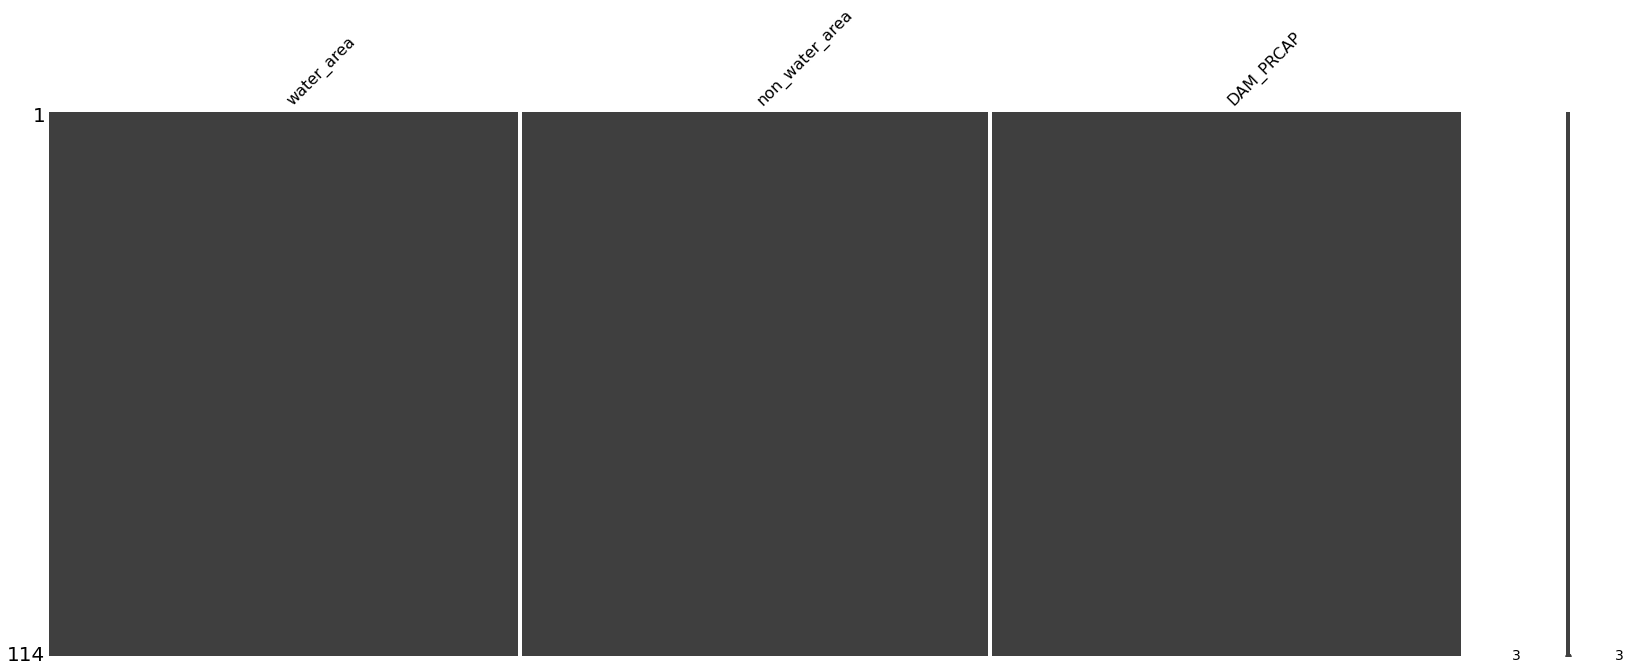

In [24]:
msno.matrix(df)

<AxesSubplot:>

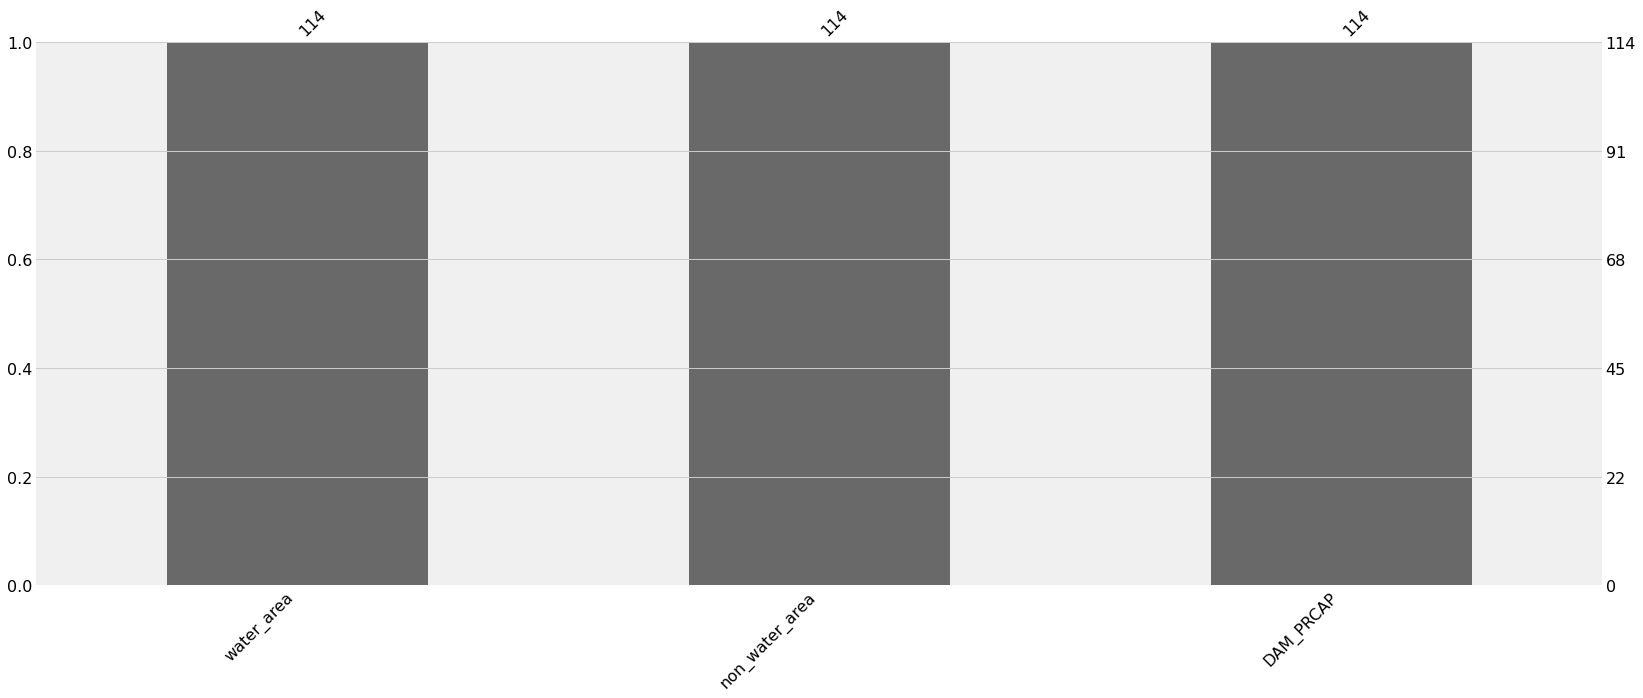

In [25]:
msno.bar(df)

In [26]:
print(sns.__version__)

# If seaborn version below 0.11.0 please upgrade seaborn version

0.11.2


<Figure size 1152x576 with 0 Axes>

Text(0.5, 1.0, 'Mutirikwi Class Area Size Plot')

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Area sq_m')

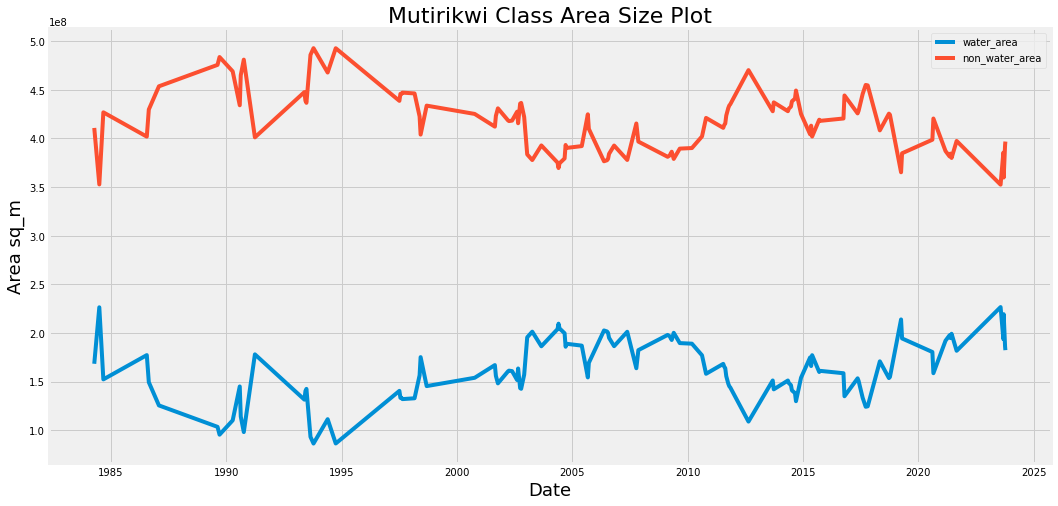

In [27]:
# Visualising the confimed cases history
plt.figure(figsize=(16,8))
plt.title('Mutirikwi Class Area Size Plot', fontsize=22)
plt.plot(df[['water_area', 'non_water_area']])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Area sq_m', fontsize=18)
plt.legend(labels = df[['water_area', 'non_water_area']].columns)
plt.show()

<Figure size 1152x576 with 0 Axes>

Text(0.5, 1.0, 'Mutirikwi Class Area Size Plot')

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Capacity Cubic_meters')

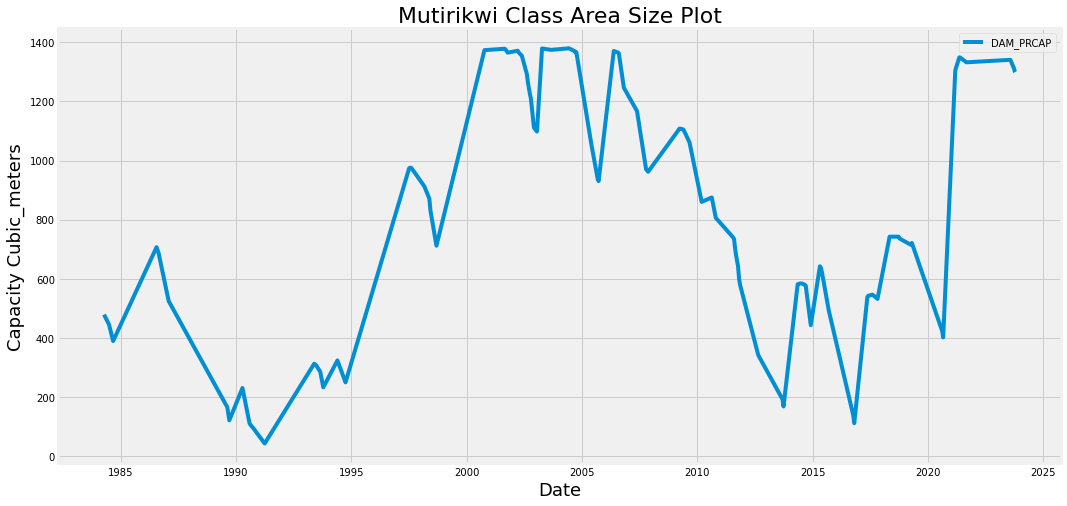

In [28]:
# Visualising the confimed cases history
plt.figure(figsize=(16,8))
plt.title('Mutirikwi Class Area Size Plot', fontsize=22)
plt.plot(df[['DAM_PRCAP']])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Capacity Cubic_meters', fontsize=18)
plt.legend(labels = df[['DAM_PRCAP']].columns)
plt.show()

In [29]:
# Statistical descrption of dataset

df.describe()

,water_area,non_water_area,DAM_PRCAP
count,1.140000e+02,1.140000e+02,114.000000
mean,1.622900e+08,4.169349e+08,831.172763
std,3.085679e+07,3.085679e+07,419.239341
min,8.645432e+07,3.525312e+08,42.864000
25%,1.435748e+08,3.922844e+08,533.410250
50%,1.603058e+08,4.189192e+08,774.248500
75%,1.869406e+08,4.356502e+08,1297.366250
max,2.266937e+08,4.927706e+08,1379.973000


In [30]:
# Checking observation at end of Dataset

df.tail()

,water_area,non_water_area,DAM_PRCAP
date,,,
2023-07-29,2.266937e+08,3.525312e+08,1340.591
2023-09-11,1.937963e+08,3.854287e+08,1318.409
2023-09-16,2.193807e+08,3.598442e+08,1317.480
2023-10-08,1.862275e+08,3.929975e+08,1301.014
2023-10-13,1.824201e+08,3.968048e+08,1299.182


Checking date ranges for the dataset

In [31]:
df_range = df.index[-1]-df.index[0]

df_range

Timedelta('14428 days 00:00:00')

In [32]:
print("Start and end date for df dataframe are {} and {} respectively".format(df.index[0],df.index[-1]))

Start and end date for df dataframe are 1984-04-12 00:00:00 and 2023-10-13 00:00:00 respectively


Checking <b>count</b> or <b>number of observations</b> in the dataset

In [33]:
len(df)

114

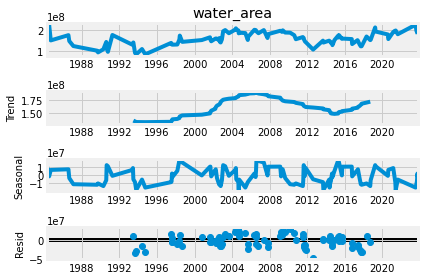

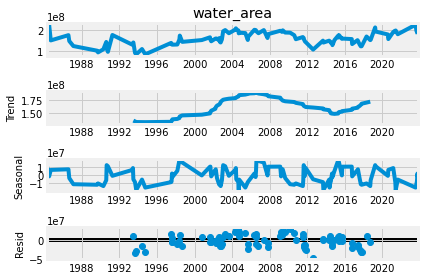

In [34]:
# Decompose different Time Series elements e.g. Seasonality, Trend, Residual etc

decomposition = sm.tsa.seasonal_decompose(df.water_area, model = 'additive', period = 30)
decomposition.plot()
plt.show()

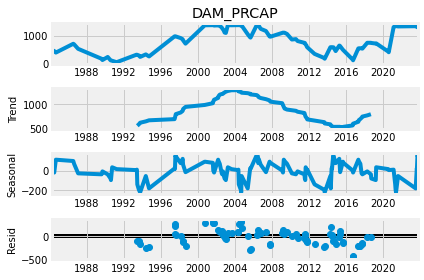

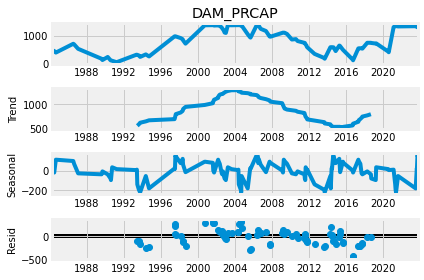

In [35]:
decomposition = sm.tsa.seasonal_decompose(df.DAM_PRCAP, model = 'additive', period = 30)
decomposition.plot()
plt.show()

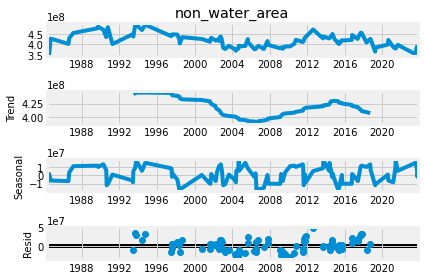

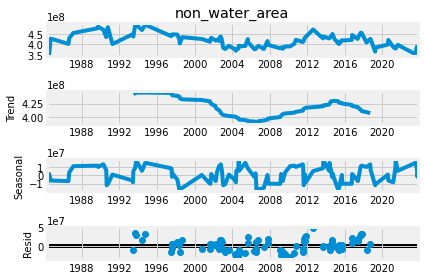

In [36]:
decomposition = sm.tsa.seasonal_decompose(df.non_water_area, model = 'additive', period = 30)
decomposition.plot()
plt.show()

<AxesSubplot:xlabel='Lag', ylabel='Autocorrelation'>

<function matplotlib.pyplot.show(close=None, block=None)>

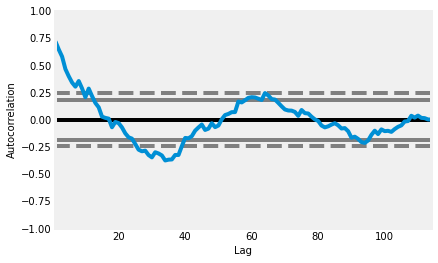

In [37]:
# Auto-correlation plot

autocorrelation_plot(df.water_area)
plt.show

<AxesSubplot:xlabel='Lag', ylabel='Autocorrelation'>

<function matplotlib.pyplot.show(close=None, block=None)>

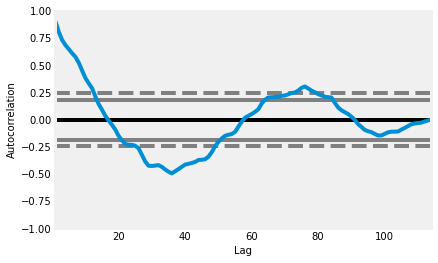

In [38]:
autocorrelation_plot(df.DAM_PRCAP)
plt.show

<AxesSubplot:xlabel='Lag', ylabel='Autocorrelation'>

<function matplotlib.pyplot.show(close=None, block=None)>

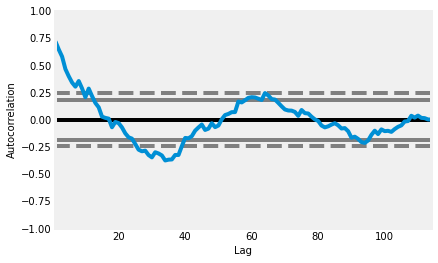

In [39]:
autocorrelation_plot(df.non_water_area)
plt.show

<AxesSubplot:xlabel='Lag', ylabel='Autocorrelation'>

<function matplotlib.pyplot.show(close=None, block=None)>

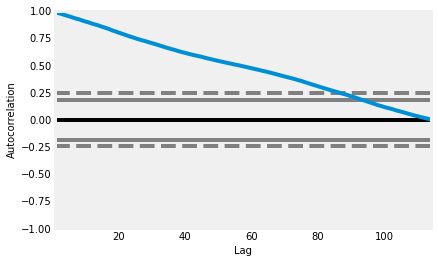

In [40]:
autocorrelation_plot(df)
plt.show

<hr style='height: 1px; background-color: black; border: none;'>

## Section 4: Detailed Feature Engineering

After the data is ready, the next step is feature engineering. It is the most critical step in building traditional machine learning models. At first, why feature engineering? Feature engineering means transforming the data from its current form to another form that serves the problem being solved. How the data is transformed from one form to another? It is using feature descriptors. 


#### 4.1 Data Transformation

<b>Multivariate CNN Models</b>
Multivariate time series data means data where there is more than one observation for each time step.

There are two main models that we may require with multivariate time series data; they are:

* Multiple Input Series.
* Multiple Parallel Series.


<b>Multiple Input Series</b>
A problem may have two or more parallel input time series and an output time series that is dependent on the input time series.

The input time series are parallel because each series has observations at the same time steps.

Next, we need to be able to frame the multivariate series of observations as a supervised learning problem so that we can train neural network models.

A supervised learning framing of a series means that the data needs to be split into multiple examples that the model learn from and generalize across.

As with the univariate time series, we must structure these data into samples with input and output samples.

A 1D CNN model needs sufficient context to learn a mapping from an input sequence to an output value. CNNs can support parallel input time series as separate channels, like red, green, and blue components of an image. Therefore, we need to split the data into samples maintaining the order of observations across the two input sequences.



In [41]:
df.columns

Index(['water_area', 'non_water_area', 'DAM_PRCAP'], dtype='object')

### Data Scaling

In [42]:
#### multivariate data preparation
water_area = array(df['water_area'])
non_water_area = array(df['non_water_area'])
dam_cap = array(df['DAM_PRCAP'])

# convert to [rows, columns] structure
water_area = water_area.reshape((len(water_area), 1))
non_water_area = non_water_area.reshape((len(non_water_area), 1))
dam_cap = dam_cap.reshape((len(dam_cap), 1))

# Initialize scaler
scaler = MinMaxScaler()

# Checking Train and Test data shapes
water_area, non_water_area, dam_cap = scaler.fit_transform(water_area), scaler.fit_transform(non_water_area), scaler.fit_transform(dam_cap)


# horizontally stack columns
dataset = hstack((water_area, non_water_area, dam_cap))
print(dataset)

[[5.84517785e-01 4.15482215e-01 3.26149925e-01]
 [9.98377782e-01 1.62221767e-03 3.00718191e-01]
 [4.70043825e-01 5.29956175e-01 2.59083590e-01]
 [6.48124910e-01 3.51875090e-01 4.96646870e-01]
 [4.49365318e-01 5.50634682e-01 4.81888911e-01]
 [2.79353796e-01 7.20646204e-01 3.60341603e-01]
 [1.22287851e-01 8.77712149e-01 9.20283986e-02]
 [6.49504165e-02 9.35049583e-01 5.85831073e-02]
 [1.69801302e-01 8.30198698e-01 1.40514348e-01]
 [4.18273744e-01 5.81726256e-01 5.13922201e-02]
 [1.97778580e-01 8.02221420e-01 4.70522598e-02]
 [8.40456888e-02 9.15954311e-01 3.80440188e-02]
 [6.53476180e-01 3.46523820e-01 0.00000000e+00]
 [3.21615110e-01 6.78384890e-01 2.01856393e-01]
 [3.84599049e-01 6.15400951e-01 1.99938823e-01]
 [4.00520228e-01 5.99479772e-01 1.97753511e-01]
 [4.90072417e-02 9.50992758e-01 1.81522972e-01]
 [0.00000000e+00 1.00000000e+00 1.42083405e-01]
 [1.78364945e-01 8.21635055e-01 2.10205750e-01]
 [3.34646256e-04 9.99665354e-01 1.54706161e-01]
 [3.85912492e-01 6.14087508e-01 6.964413

#### 4.2 Train Test split

The first step is to split the loaded series into train and test sets.

The train_test_split() function below will split the series taking the 80% of the raw observations and the number of observations to use in the test set as arguments.

In [43]:
len(dataset)

114

In [44]:
# Creating a new dataframe with only the Zimbabwe column
print(len(dataset))
#Converting the dataframe to a numpy array
#data = dataset.values
#Getting the number of rows to train the model on
n_test = math.ceil(len(dataset)*0.8)
n_test

114


92

In [45]:
# split a univariate dataset into train/test sets

test, train = dataset[:-n_test], dataset[-n_test:]

In [46]:
# split a multivariate sequence into samples
def split_sequences(sequences, n_steps):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps
        # check if we are beyond the dataset
        if end_ix > len(sequences):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :-1], sequences[end_ix-1, -1]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [47]:
# convert into input/output
n_steps = 3
train_x, train_y = split_sequences(train, n_steps)
print(train_x.shape, train_y.shape)

# summarize the data
for i in range(len(train_x)):
    print(train_x[i], train_y[i])

(90, 3, 2) (90,)
[[0.33547986 0.66452014]
 [0.32556276 0.67443724]
 [0.33163859 0.66836141]] 0.6505752335823034
[[0.32556276 0.67443724]
 [0.33163859 0.66836141]
 [0.50021992 0.49978008]] 0.6192157856988474
[[0.33163859 0.66836141]
 [0.50021992 0.49978008]
 [0.63315774 0.36684226]] 0.5903056519700339
[[0.50021992 0.49978008]
 [0.63315774 0.36684226]
 [0.42096863 0.57903137]] 0.5003758107977735
[[0.63315774 0.36684226]
 [0.42096863 0.57903137]
 [0.48182273 0.51817727]] 0.9950542551130837
[[0.42096863 0.57903137]
 [0.48182273 0.51817727]
 [0.57503857 0.42496143]] 0.9985857547888768
[[0.48182273 0.51817727]
 [0.57503857 0.42496143]
 [0.49591283 0.50408717]] 0.9964655087954686
[[0.57503857 0.42496143]
 [0.49591283 0.50408717]
 [0.4409444  0.5590556 ]] 0.9887167014805824
[[0.49591283 0.50408717]
 [0.4409444  0.5590556 ]
 [0.52904113 0.47095887]] 0.9936437493128834
[[0.4409444  0.5590556 ]
 [0.52904113 0.47095887]
 [0.53408989 0.46591011]] 0.9887167014805824
[[0.52904113 0.47095887]
 [0.5340

In [48]:
n_steps = 3
test_x, test_y = split_sequences(test, n_steps)
print(test_x.shape, test_y.shape)

# summarize the data
for i in range(len(test_x)):
    print(test_x[i], test_y[i])

(20, 3, 2) (20,)
[[0.58451778 0.41548222]
 [0.99837778 0.00162222]
 [0.47004382 0.52995618]] 0.25908359004389325
[[0.99837778 0.00162222]
 [0.47004382 0.52995618]
 [0.64812491 0.35187509]] 0.4966468702252397
[[0.47004382 0.52995618]
 [0.64812491 0.35187509]
 [0.44936532 0.55063468]] 0.48188891107606047
[[0.64812491 0.35187509]
 [0.44936532 0.55063468]
 [0.2793538  0.7206462 ]] 0.3603416026666487
[[0.44936532 0.55063468]
 [0.2793538  0.7206462 ]
 [0.12228785 0.87771215]] 0.09202839858231454
[[0.2793538  0.7206462 ]
 [0.12228785 0.87771215]
 [0.06495042 0.93504958]] 0.05858310728594304
[[0.12228785 0.87771215]
 [0.06495042 0.93504958]
 [0.1698013  0.8301987 ]] 0.14051434849365313
[[0.06495042 0.93504958]
 [0.1698013  0.8301987 ]
 [0.41827374 0.58172626]] 0.05139222008078624
[[0.1698013  0.8301987 ]
 [0.41827374 0.58172626]
 [0.19777858 0.80222142]] 0.047052259763414955
[[0.41827374 0.58172626]
 [0.19777858 0.80222142]
 [0.08404569 0.91595431]] 0.03804401884962259
[[0.19777858 0.80222142]

In [49]:
train_x.shape, train_y.shape, test_x.shape, test_y.shape

((90, 3, 2), (90,), (20, 3, 2), (20,))

<hr style='height: 1px; background-color: black; border: none;'>

## Section 5: Explanation of Machine Learning / Deep learning algorithm and parameters used

#### 5.1 Convolutional Neural Network Model
Convolutional Neural Networks, or CNNs, are a type of neural network developed for two-dimensional image data, although they can be used for one-dimensional data such as sequences of text and time series.

When operating on one-dimensional data, the CNN reads across a sequence of lag observations and learns to extract features that are relevant for making a prediction.

We will define a CNN with two convolutional layers for extracting features from the input sequences. Each will have a configurable number of filters and kernel size and will use the rectified linear activation function. The number of filters determines the number of parallel fields on which the weighted inputs are read and projected. The kernel size defines the number of time steps read within each snapshot as the network reads along the input sequence.

A max pooling layer is used after convolutional layers to distill the weighted input features into those that are most salient, reducing the input size by 1/4. The pooled inputs are flattened to one long vector before being interpreted and used to make a one-step prediction.

The CNN model expects input data to be in the form of multiple samples, where each sample has multiple input time steps, the same as the MLP in the previous section.

One difference is that the CNN can support multiple features or types of observations at each time step, which are interpreted as channels of an image. We only have a single feature at each time step, therefore the required three-dimensional shape of the input data will be [n_samples, n_input, 1].

In [ ]:
# define model
n_features = train_x.shape[2]
n_steps = 3
model = Sequential()
model.add(Conv1D(filters=32, kernel_size=2, activation='tanh', input_shape=(n_steps, n_features)))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(64, activation='tanh'))
model.add(Dense(1))
model.compile(optimizer='adamax', loss='mse', metrics = ['mse','accuracy'])

In [50]:
# define model
n_features = train_x.shape[2]
n_steps = 3
model = Sequential()
model.add(Conv1D(filters=64, kernel_size=2, activation='tanh', input_shape=(n_steps, n_features)))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(1000, activation='tanh'))
model.add(Dense(500, activation='tanh'))
model.add(Dense(250, activation='tanh'))
model.add(Dense(1))
model.compile(optimizer='adamax', loss='mse', metrics = ['mse','accuracy'])

#### 5.2 Explanation of Deep learning parameters used


CNN is a type of neural network model which allows us to extract higher representations for the image content. Unlike the classical image recognition where you define the image features yourself, CNN takes the image's raw pixel data, trains the model, then extracts the features automatically for better classification.

The CNN model has two parts, that baseModel and the topModel.

#### 5.2.1 BaseModel
This layer is where transfer learning occurs, as we inherit the ResNet50V2 trained network parameters to utilise in our model. The inheritance is done by importing the weights of the original model which is accomplished by command "weights='imagenet'". Include_top is set to false so as not to inherit the fully connected layer of the ResNet50V2 model but replace it with our own custom made fully connected layer. After importing the baseModel the next step will be to build our fully connected layer or topModel.

#### 5.2.2 TopModel
On the top model Flatten layer was utilised. Softmax activation function was also utlised. This section will detail how each of these parameters affect performance of the dense layer and justification for their inclusion.

#### 5.2.3 Flattening
Flattening and fully-connected layers are what we have at the last stage of CNN. Flattening is converting the data into a 1-dimensional array for inputting it to the next layer which is mostly the fully connected layer which is the final classification model. We flatten the output of the convolutional layers to create a single long feature vector. In other words, we put all the pixel data in one line and make connections with the final layer, see below figure 3

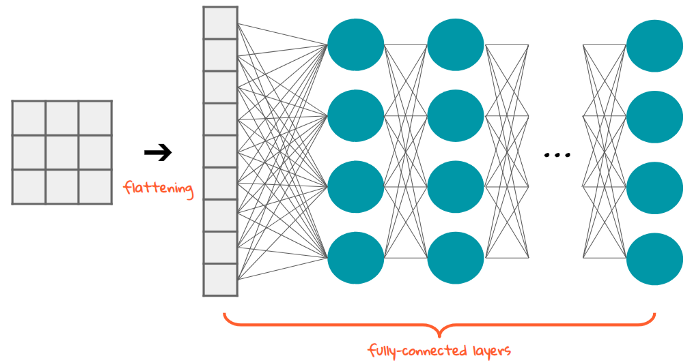
Figure 2. Adapted from (https://towardsdatascience.com/the-most-intuitive-and-easiest-guide-for-convolutional-neural-network-3607be47480)


#### 5.2.4 Dense 

A dense layer is just a regular layer of neurons in a neural network. Each neuron recieves input from all the neurons in the previous layer, thus densely connected. The layer has a weight matrix W, <b>a</b> bias vector <b>b</b>, and the activations of previous layer <b>a</b>. Dense connection is illustrated by figure 4 below

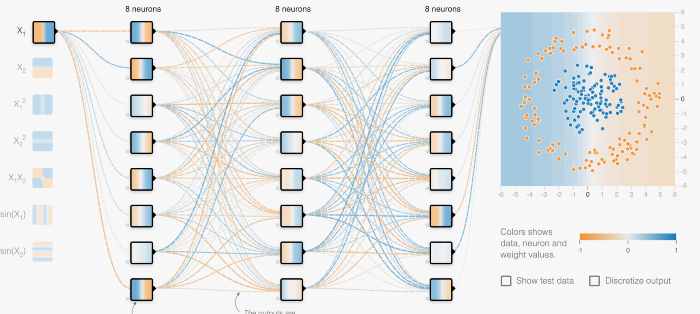
Figure 6. Adapted from (https://heartbeat.fritz.ai/classification-with-tensorflow-and-dense-neural-networks-8299327a818a)

#### 5.2.5 Rectified Linear Activation Function
The rectified linear activation function or ReLU for short is a piecewise linear function that will output the input directly if it is positive, otherwise, it will output zero. It has become the default activation function for many types of neural networks because a model that uses it is easier to train and often achieves better performance.


#### 5.3 Application of model checkpointing and Early stopping

#### 5.3.1 Early Stopping
In machine learning, early stopping is a form of regularisation used to avoid overfitting when training a learner with an iterative method, such as gradient descent. Such methods update the learner so as to make it better fit the training data with each iteration.

If the performance of the model on the validation dataset starts to degrade (e.g. loss begins to increase, or accuracy begins to decrease), then the training process is stopped. The model at this stage have low variance and is known to generalize the data well. Training the model further would increase the variance of the model and lead to overfitting. 

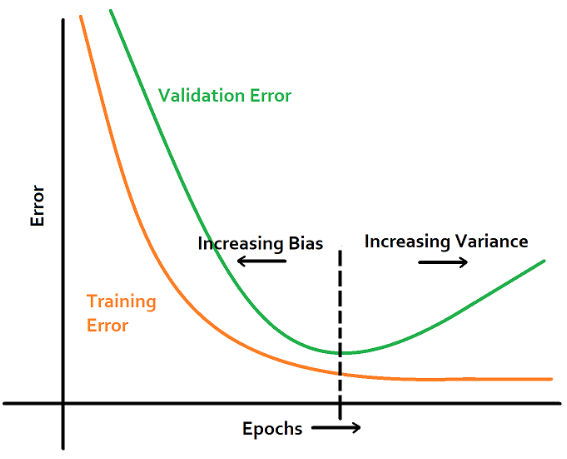
Figure 4. Illustration of Early stopping adapted from (https://medium.com/@rahuljain13101999/why-early-stopping-works-as-regularization-b9f0a6c2772)

#### 5.3.2 Model checkpointing
Rather than building a new model from scratch, checkpoint option can be used to create a new model based on the existing model. The checkpoint option is available for DRF, GBM, XGBoost and Deep Learning algorithms. This allows specification of a model key associated with a previously trained model. This will build a new model as a continuation of a previously generated model. If this is not specified, then the algorithm will start training a new model instead of continuing building a previous model.

<hr style='height: 1px; background-color: black; border: none;'>

## Section 6: Architecture diagram of Machine learning / Deep learning algorithm


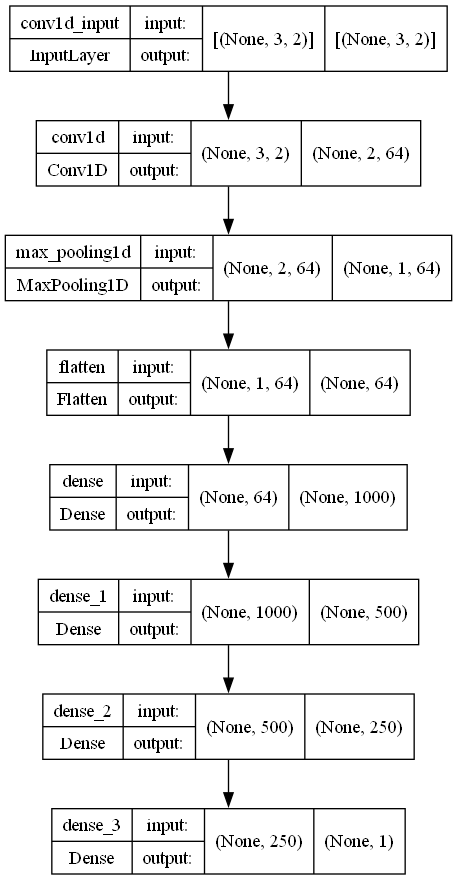

In [51]:
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [52]:
# Model checkpointing
filepath = "weights-improvement-{epoch:02d}-{val_loss:.2f}.h5"
checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=1, save_best_only=True, mode='min')

In [53]:
# Early stopping
earlystop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

In [54]:
history = model.fit(train_x, train_y, validation_split=0.2, epochs=100, batch_size=30, callbacks=[earlystop, checkpoint], verbose=1)

Epoch 1/100
1/3 [=========>....................] - ETA: 0s - loss: 0.3522 - mse: 0.3522 - accuracy: 0.0000e+00
Epoch 1: val_loss improved from inf to 0.05029, saving model to weights-improvement-01-0.05.h5
3/3 [==============================] - 1s 90ms/step - loss: 0.7014 - mse: 0.7014 - accuracy: 0.0139 - val_loss: 0.0503 - val_mse: 0.0503 - val_accuracy: 0.0000e+00
Epoch 2/100
1/3 [=========>....................] - ETA: 0s - loss: 0.0589 - mse: 0.0589 - accuracy: 0.0000e+00
Epoch 2: val_loss did not improve from 0.05029
3/3 [==============================] - 0s 14ms/step - loss: 0.1467 - mse: 0.1467 - accuracy: 0.0139 - val_loss: 0.2419 - val_mse: 0.2419 - val_accuracy: 0.0000e+00
Epoch 3/100
1/3 [=========>....................] - ETA: 0s - loss: 0.2781 - mse: 0.2781 - accuracy: 0.0000e+00
Epoch 3: val_loss did not improve from 0.05029
3/3 [==============================] - 0s 14ms/step - loss: 0.2095 - mse: 0.2095 - accuracy: 0.0000e+00 - val_loss: 0.0725 - val_mse: 0.0725 - val_acc

Epoch 26/100
1/3 [=========>....................] - ETA: 0s - loss: 0.0494 - mse: 0.0494 - accuracy: 0.0000e+00
Epoch 26: val_loss did not improve from 0.04720
3/3 [==============================] - 0s 14ms/step - loss: 0.0478 - mse: 0.0478 - accuracy: 0.0139 - val_loss: 0.0484 - val_mse: 0.0484 - val_accuracy: 0.0000e+00
Epoch 27/100
1/3 [=========>....................] - ETA: 0s - loss: 0.0540 - mse: 0.0540 - accuracy: 0.0333
Epoch 27: val_loss did not improve from 0.04720
3/3 [==============================] - 0s 14ms/step - loss: 0.0476 - mse: 0.0476 - accuracy: 0.0139 - val_loss: 0.0486 - val_mse: 0.0486 - val_accuracy: 0.0000e+00
Epoch 28/100
1/3 [=========>....................] - ETA: 0s - loss: 0.0421 - mse: 0.0421 - accuracy: 0.0333
Epoch 28: val_loss did not improve from 0.04720
3/3 [==============================] - 0s 14ms/step - loss: 0.0476 - mse: 0.0476 - accuracy: 0.0139 - val_loss: 0.0481 - val_mse: 0.0481 - val_accuracy: 0.0000e+00
Epoch 29/100
1/3 [=========>........

Epoch 51/100
1/3 [=========>....................] - ETA: 0s - loss: 0.0439 - mse: 0.0439 - accuracy: 0.0000e+00
Epoch 51: val_loss did not improve from 0.04663
3/3 [==============================] - 0s 14ms/step - loss: 0.0472 - mse: 0.0472 - accuracy: 0.0139 - val_loss: 0.0471 - val_mse: 0.0471 - val_accuracy: 0.0000e+00
Epoch 52/100
1/3 [=========>....................] - ETA: 0s - loss: 0.0759 - mse: 0.0759 - accuracy: 0.0000e+00
Epoch 52: val_loss did not improve from 0.04663
3/3 [==============================] - 0s 14ms/step - loss: 0.0474 - mse: 0.0474 - accuracy: 0.0139 - val_loss: 0.0470 - val_mse: 0.0470 - val_accuracy: 0.0000e+00
Epoch 53/100
1/3 [=========>....................] - ETA: 0s - loss: 0.0339 - mse: 0.0339 - accuracy: 0.0333
Epoch 53: val_loss did not improve from 0.04663
3/3 [==============================] - 0s 13ms/step - loss: 0.0474 - mse: 0.0474 - accuracy: 0.0139 - val_loss: 0.0476 - val_mse: 0.0476 - val_accuracy: 0.0000e+00
Epoch 54/100
1/3 [=========>....

<Figure size 720x432 with 0 Axes>

Text(0.5, 1.0, 'Model Loss Over Epochs')

Text(0.5, 0, 'Epochs')

Text(0, 0.5, 'Mean Squared Error (Loss)')

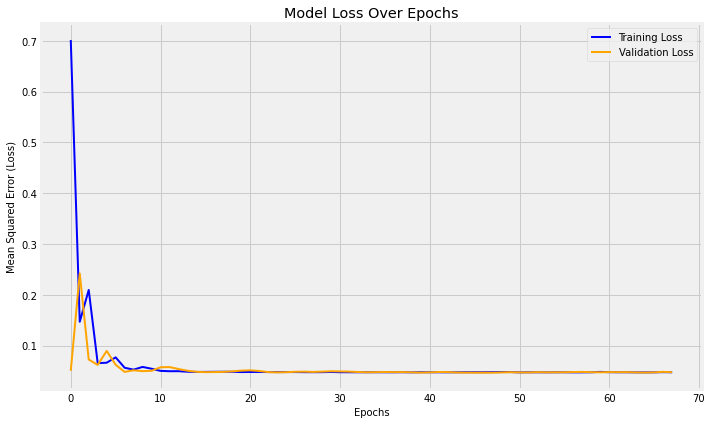

In [55]:
# Plot loss curves
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)

plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


<hr style='height: 1px; background-color: black; border: none;'>

## Section 7: Demonstrate Hyperparameter Tuning done to boost performance of the model

In machine learning, hyperparameter optimization or tuning is the problem of choosing a set of optimal hyperparameters for a learning algorithm. A hyperparameter is a parameter whose value is used to control the learning process. By contrast, the values of other parameters (typically node weights) are learned.

In machine learning, hyperparameter optimization or tuning is the problem of choosing a set of optimal hyperparameters for a learning algorithm. A hyperparameter is a parameter whose value is used to control the learning process. By contrast, the values of other parameters (typically node weights) are learned. In this article of the two methods of hyperparameter tuning, Grid Search will be utilised.

#### 7.1 GridSearch
Grid search is the simplest algorithm for hyperparameter tuning. Basically, we divide the domain of the hyperparameters into a discrete grid. Then, we try every combination of values of this grid, calculating some performance metrics using cross-validation. The point of the grid that maximizes the average value in cross-validation, is the optimal combination of values for the hyperparameters.

In [56]:
def create_model(optimizer='adam',activation='tanh'):
    # Create model
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=2, activation=activation, input_shape=(n_steps, n_features)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())
    model.add(Dense(1000, activation = activation))
    model.add(Dense(500, activation = activation))
    model.add(Dense(250, activation = activation))
    model.add(Dense(1))
    # Compile model
    model.compile(loss='mse', optimizer=optimizer, metrics = ['mse','accuracy'])
    return model

In [57]:
model = KerasRegressor(build_fn=create_model, verbose=1)

In [58]:
optimizers = ['adam','adamax','SGD', 'adagrad']
activation = ['relu', 'tanh', 'selu']

In [59]:
param_grid = dict(optimizer=optimizers, activation = activation)

In [60]:
grid = GridSearchCV(estimator=model, param_grid=param_grid)

In [61]:
grid_result = grid.fit(train_x, train_y)

3/3 [==============================] - 1s 5ms/step - loss: 0.6543 - mse: 0.6543 - accuracy: 0.0111


In [62]:
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']

Best: -0.061589 using {'activation': 'tanh', 'optimizer': 'adamax'}


In [63]:
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

-0.074063 (0.020349) with: {'activation': 'relu', 'optimizer': 'adam'}
-0.096320 (0.042204) with: {'activation': 'relu', 'optimizer': 'adamax'}
-0.378634 (0.215226) with: {'activation': 'relu', 'optimizer': 'SGD'}
-0.481188 (0.254188) with: {'activation': 'relu', 'optimizer': 'adagrad'}
-0.164922 (0.145350) with: {'activation': 'tanh', 'optimizer': 'adam'}
-0.061589 (0.029979) with: {'activation': 'tanh', 'optimizer': 'adamax'}
-0.095500 (0.068144) with: {'activation': 'tanh', 'optimizer': 'SGD'}
-0.292055 (0.199821) with: {'activation': 'tanh', 'optimizer': 'adagrad'}
-1.740530 (0.835828) with: {'activation': 'selu', 'optimizer': 'adam'}
-0.113536 (0.064628) with: {'activation': 'selu', 'optimizer': 'adamax'}
-5.145133 (8.559298) with: {'activation': 'selu', 'optimizer': 'SGD'}
-0.067123 (0.033409) with: {'activation': 'selu', 'optimizer': 'adagrad'}


#### 7.2 Remodelling using best parameters

In [64]:
# Best: -18414073.687500 using {'activation': 'selu', 'optimizer': 'adagrad'}

bestParams = {'activation': 'tanh', 'optimizer': 'adamax'}
model = Sequential()
model.add(Conv1D(filters=64, kernel_size=2, activation=bestParams['activation'], input_shape=(n_steps, n_features)))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(1000, activation = bestParams['activation']))
model.add(Dense(500, activation = bestParams['activation']))
model.add(Dense(250, activation = bestParams['activation']))
model.add(Dense(1))
    # Compile model
model.compile(loss='mse', optimizer=bestParams['optimizer'], metrics = ['mse','accuracy'])
    

In [65]:
history = model.fit(train_x, train_y, validation_split=0.2, epochs=100, batch_size=30, callbacks=[earlystop, checkpoint], verbose=1)

Epoch 1/100
1/3 [=========>....................] - ETA: 0s - loss: 0.6333 - mse: 0.6333 - accuracy: 0.0000e+00
Epoch 1: val_loss did not improve from 0.04663
3/3 [==============================] - 0s 60ms/step - loss: 0.7252 - mse: 0.7252 - accuracy: 0.0139 - val_loss: 0.0771 - val_mse: 0.0771 - val_accuracy: 0.0000e+00
Epoch 2/100
1/3 [=========>....................] - ETA: 0s - loss: 0.0765 - mse: 0.0765 - accuracy: 0.0000e+00
Epoch 2: val_loss did not improve from 0.04663
3/3 [==============================] - 0s 17ms/step - loss: 0.1537 - mse: 0.1537 - accuracy: 0.0000e+00 - val_loss: 0.2951 - val_mse: 0.2951 - val_accuracy: 0.0000e+00
Epoch 3/100
1/3 [=========>....................] - ETA: 0s - loss: 0.2286 - mse: 0.2286 - accuracy: 0.0000e+00
Epoch 3: val_loss did not improve from 0.04663
3/3 [==============================] - 0s 14ms/step - loss: 0.2216 - mse: 0.2216 - accuracy: 0.0000e+00 - val_loss: 0.0867 - val_mse: 0.0867 - val_accuracy: 0.0000e+00
Epoch 4/100
1/3 [=========

Epoch 26/100
1/3 [=========>....................] - ETA: 0s - loss: 0.0482 - mse: 0.0482 - accuracy: 0.0000e+00
Epoch 26: val_loss improved from 0.04551 to 0.04541, saving model to weights-improvement-26-0.05.h5
3/3 [==============================] - 0s 32ms/step - loss: 0.0480 - mse: 0.0480 - accuracy: 0.0139 - val_loss: 0.0454 - val_mse: 0.0454 - val_accuracy: 0.0000e+00
Epoch 27/100
1/3 [=========>....................] - ETA: 0s - loss: 0.0539 - mse: 0.0539 - accuracy: 0.0000e+00
Epoch 27: val_loss did not improve from 0.04541
3/3 [==============================] - 0s 16ms/step - loss: 0.0481 - mse: 0.0481 - accuracy: 0.0139 - val_loss: 0.0457 - val_mse: 0.0457 - val_accuracy: 0.0000e+00
Epoch 28/100
1/3 [=========>....................] - ETA: 0s - loss: 0.0438 - mse: 0.0438 - accuracy: 0.0000e+00
Epoch 28: val_loss did not improve from 0.04541
3/3 [==============================] - 0s 13ms/step - loss: 0.0480 - mse: 0.0480 - accuracy: 0.0139 - val_loss: 0.0463 - val_mse: 0.0463 - v

Epoch 51/100
1/3 [=========>....................] - ETA: 0s - loss: 0.0507 - mse: 0.0507 - accuracy: 0.0333
Epoch 51: val_loss did not improve from 0.04498
3/3 [==============================] - 0s 13ms/step - loss: 0.0474 - mse: 0.0474 - accuracy: 0.0139 - val_loss: 0.0466 - val_mse: 0.0466 - val_accuracy: 0.0000e+00
Epoch 52/100
1/3 [=========>....................] - ETA: 0s - loss: 0.0523 - mse: 0.0523 - accuracy: 0.0000e+00
Epoch 52: val_loss did not improve from 0.04498
3/3 [==============================] - 0s 15ms/step - loss: 0.0473 - mse: 0.0473 - accuracy: 0.0139 - val_loss: 0.0458 - val_mse: 0.0458 - val_accuracy: 0.0000e+00
Epoch 53/100
1/3 [=========>....................] - ETA: 0s - loss: 0.0496 - mse: 0.0496 - accuracy: 0.0000e+00
Epoch 53: val_loss did not improve from 0.04498
3/3 [==============================] - 0s 15ms/step - loss: 0.0476 - mse: 0.0476 - accuracy: 0.0139 - val_loss: 0.0453 - val_mse: 0.0453 - val_accuracy: 0.0000e+00
Epoch 54/100
1/3 [=========>....

Epoch 76/100
1/3 [=========>....................] - ETA: 0s - loss: 0.0531 - mse: 0.0531 - accuracy: 0.0000e+00
Epoch 76: val_loss did not improve from 0.04423
3/3 [==============================] - 0s 14ms/step - loss: 0.0472 - mse: 0.0472 - accuracy: 0.0139 - val_loss: 0.0458 - val_mse: 0.0458 - val_accuracy: 0.0000e+00
Epoch 77/100
1/3 [=========>....................] - ETA: 0s - loss: 0.0420 - mse: 0.0420 - accuracy: 0.0333
Epoch 77: val_loss did not improve from 0.04423
3/3 [==============================] - 0s 13ms/step - loss: 0.0474 - mse: 0.0474 - accuracy: 0.0139 - val_loss: 0.0455 - val_mse: 0.0455 - val_accuracy: 0.0000e+00
Epoch 78/100
1/3 [=========>....................] - ETA: 0s - loss: 0.0299 - mse: 0.0299 - accuracy: 0.0000e+00
Epoch 78: val_loss did not improve from 0.04423
3/3 [==============================] - 0s 13ms/step - loss: 0.0475 - mse: 0.0475 - accuracy: 0.0139 - val_loss: 0.0450 - val_mse: 0.0450 - val_accuracy: 0.0000e+00
Epoch 79/100
1/3 [=========>....

<Figure size 720x432 with 0 Axes>

Text(0.5, 1.0, 'Model Loss Over Epochs')

Text(0.5, 0, 'Epochs')

Text(0, 0.5, 'Mean Squared Error (Loss)')

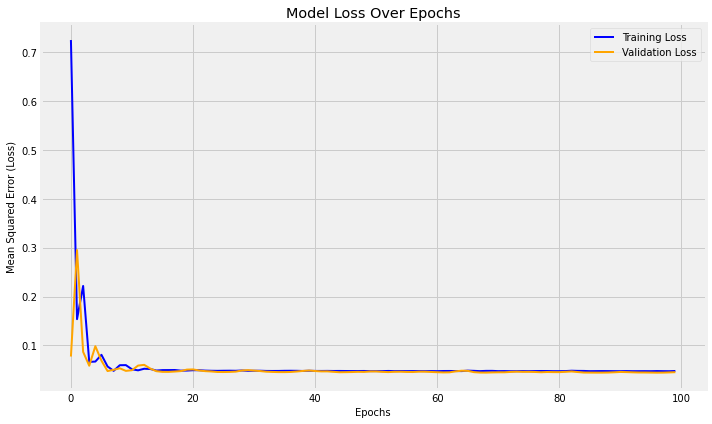

In [66]:
# Plot loss curves
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)

plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### 7.3 Initial model performance
val_loss improved from 0.04664 to 0.04663, saving model to weights-improvement-48-0.05.h5

#### 7.4 After Hyperparameter tuning

Hyper parameter tuning yielded results as Val_loss improvement from 0.04663 (in first model) to 0.04410 after hyperparameter tuning hence the new best model was saved as <b>weights-improvement-97-0.04.h5</b

In [50]:
# Loading best saved model
model = load_model('weights-improvement-97-0.04.h5')

In [51]:
Y_hat1 = model.predict(test_x)

In [52]:
# Print yhat
    
df_pred1 = pd.DataFrame.from_records(Y_hat1, columns=['Predicted'])
df_pred1 = df_pred1.reset_index(drop = True)

len(test_y), len(df_pred1.iloc[:,0])

(20, 20)

<hr style='height: 1px; background-color: black; border: none;'>

## Section 8: Performance Metrics report of the Machine learning / Deep learning algorithm

In [53]:
Predicted = array(df_pred1.iloc[:,0])
Actual = array(test_y)

# convert to [rows, columns] structure
Predicted = Predicted.reshape((len(Predicted), 1))
Actual = Actual.reshape((len(Actual), 1))

Predicted, Actual= list(scaler.inverse_transform(Predicted)), list(scaler.inverse_transform(Actual))

i = 0
pred, act = [], []
while i < len(Predicted):
    pred.append(float(str(Predicted[i]).strip(']').strip('[')))
    act.append(float(str(Actual[i]).strip(']').strip('[')))
    i += 1

comp = pd.DataFrame(zip(pred, act), columns=['Predicted', 'Actual'])

comp.head(25)

,Predicted,Actual
0,856.65936,389.287
1,698.91590,706.935
2,797.04890,687.202
3,586.94450,524.680
4,357.83010,165.916
5,223.29909,121.196
6,247.42053,230.747
7,499.56793,111.581
8,427.48474,105.778
9,273.02762,93.733


<AxesSubplot:>

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Dam Capacity')

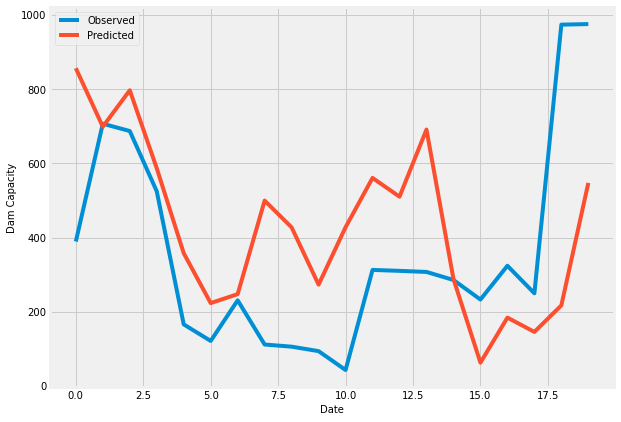

In [54]:
ax = comp['Actual'].plot(label='Observed', figsize=(9, 7))
comp['Predicted'].plot()
ax.set_xlabel('Date')
ax.set_ylabel('Dam Capacity')
plt.legend()
plt.show()

In [55]:
# Performance Report 

coefficient_of_determination = r2_score(test_y, Y_hat1)
print('R Squared: ', coefficient_of_determination)

mae = mean_absolute_error(test_y, Y_hat1)
print('The Mean Absolute Error of the model forecast is: {}'.format(round(mae, 2)))

mse = mean_squared_error(test_y, Y_hat1)
print('The Mean Square Error of the model forecast is: {}'.format(round(mse, 2)))

msle = mean_squared_log_error((test_y**2)**0.5, (Y_hat1**2)**0.5)
print('The Mean Square Log Error of the model forecast is: {}'.format(round(msle, 2)))

print('The Root Mean Square Error of the model forecast is: {}'.format(round(np.sqrt(mse), 2)))

R Squared:  -0.21715266591605897
The Mean Absolute Error of the model forecast is: 0.17
The Mean Square Error of the model forecast is: 0.05
The Mean Square Log Error of the model forecast is: 0.03
The Root Mean Square Error of the model forecast is: 0.22


<hr style='height: 1px; background-color: black; border: none;'>

## Section 9: The analytics outcome (What insights can you provide from this data)

* The dam capacity and water coverage area have strikingly similar trend lines giving strong justification of Hydrological Principle which states there exists a non-linear but physically grounded relationship between the surface area of a dam and its storage volume. This relationship is influenced by the dam’s bathymetry and catchment hydrology, and serves as the foundational assumption that variations in observed surface area reflect underlying capacity changes.
* The trend line for dam capacity showed a stready rise in capacity for about 10 to 11 years followed by a stready capacity decline for another 10 to 12 years which highly suggest could cyclical and hence water conservation and collection efforts require incorporation of this insight for higher data driven effectiveness
* The noteable drought years in Zimbabwean history were also at the lowest dam capacity pointing to potentially different outcome if efforts had been timely put to mitigate the looming danger of low water capacity coupled with terrible rainfall. If the dam capacity was higher, irrigation and other such efforts to alleviate low rainfall would have been quite successful
* The data was not continuous both for images and dam capacity level records, more efforts in data caturing and storage of such critical records would help in resources sustainable planning efforts.


<hr style='height: 1px; background-color: black; border: none;'>

## Section 10: Conclusion and Remarks

* The accuracy evaluation graph reveal the predicted graph captures the trend of the y_test graph or actual hence satisfaction the model performed for the test data.
* The model performs satisfactorily as marked with relative low MAE, MSE, MSLE and RMSE of 0.17, 0.05, 0.03 and 0.22 respectively.
* The model can be utilised to forecast dam capacity based on water area coverage into the foreseeable future with a satisfactory accuracy.